corresponding to archive-46

In [2]:
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

ub:ub1-, mean:0.9186720956994848
ub:ub1ma-, mean:0.9186720956994848
ub:ub7-, mean:0.9582867090598242
ub:ub7ma-, mean:0.9582867090598242
ub:ub1, mean:0.9206231187392625
ub:ub1ma, mean:0.9206231187392625
ub:ub7, mean:0.9581183264717915
ub:ub7ma, mean:0.9582867090598243
ub:ub11, mean:0.9611532377303219
ub:ub11m, mean:0.9611532377303219
ub:ub7u, mean:0.9611532377303217
ub:ub7mu, mean:0.9611532377303219
count:1/13 youtube_1000.pdf completed.


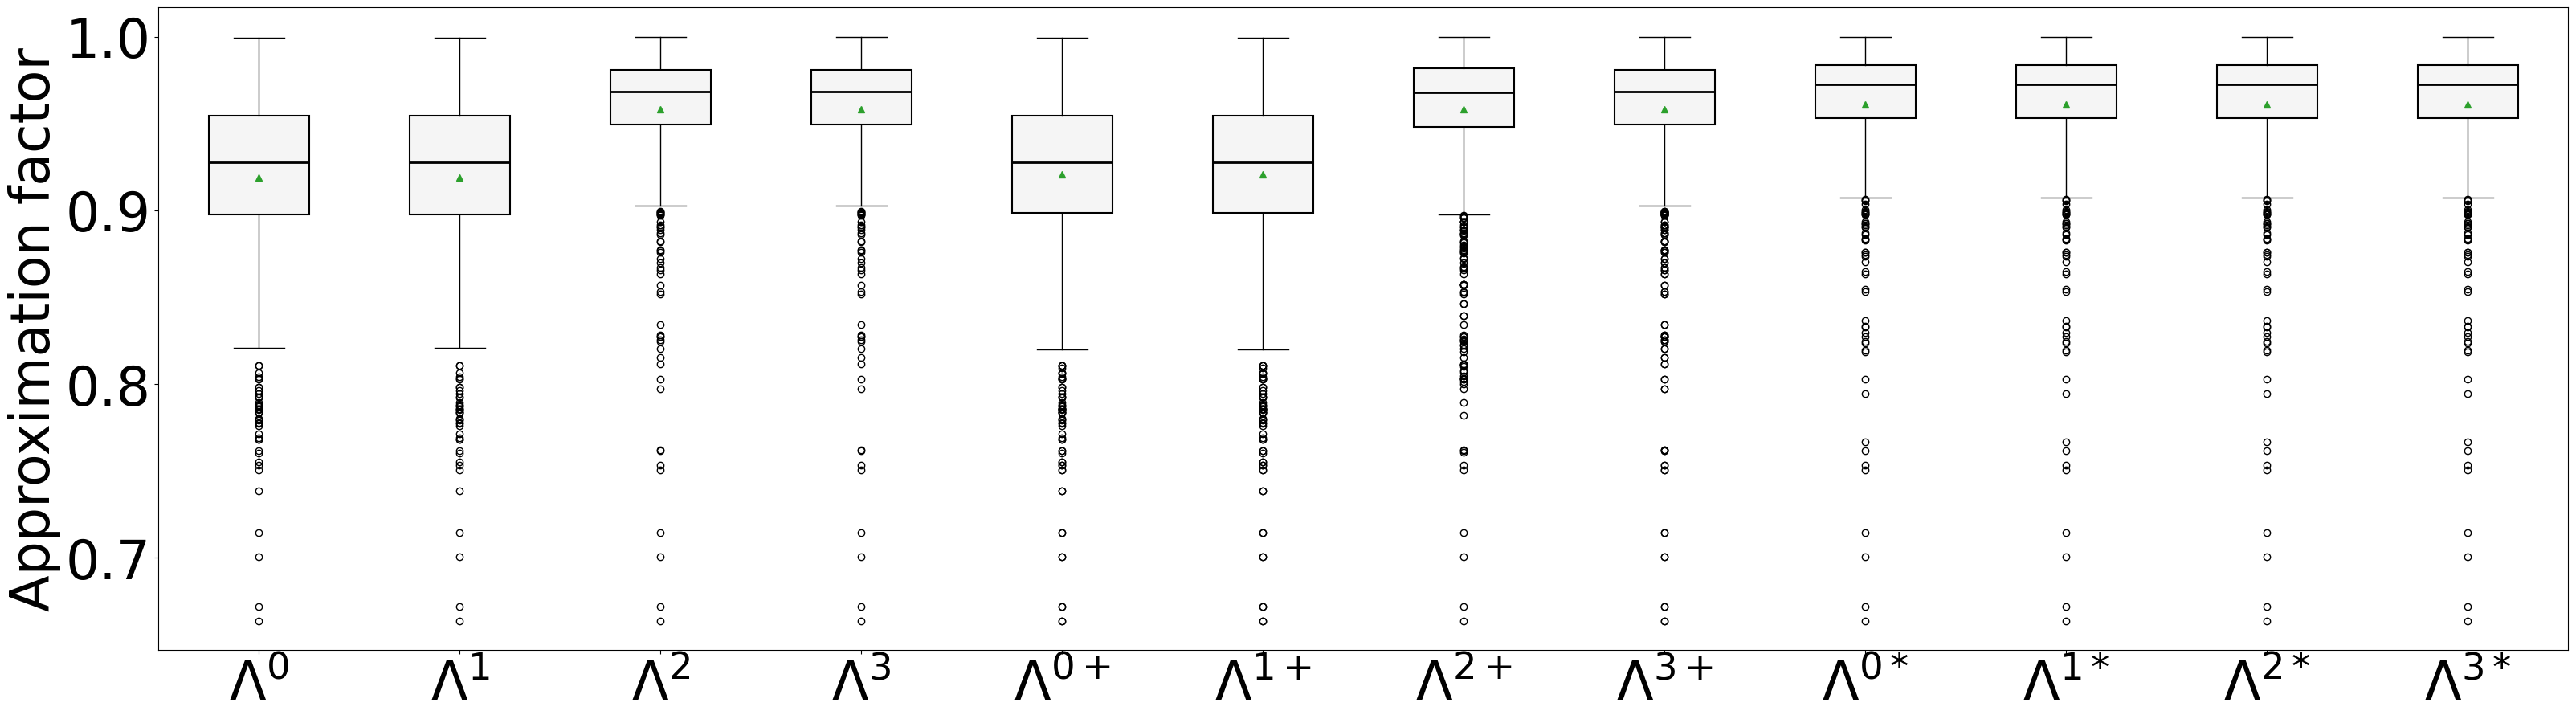

In [19]:
t = False

def load_12_series(upper_bound: str, task_name: str, source_dir: str):
    """
    kv_data has the following keys: 
    - 'S'
    - 'f(S)'
    - 'c(S)'
    - 'Lambda'
    - 'AF'
    """
    task_dict = {
        "facebook": "FacebookGraphCoverage",
        "youtube" : "YoutubeCoverage",
        "caltech": "CalTechMaximization",
        "adult": "AdultIncomeFeatureSelection"
    }

    res = []
    # print(f"r:{source_dir}")
    for name in os.listdir(source_dir):
        if not os.path.isdir(os.path.join(source_dir, name)):
            algo, up, task, budget = name.strip()[:-5].split('-')
            # print(f"algo:{algo}, up:{up}, upp:{upper_bound}")
            if up == upper_bound and task_dict[task_name] == task:
                # print(name)
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']))
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']))
            elif (up == upper_bound[:len(upper_bound)-1] and upper_bound[len(upper_bound)-1] == '-') and algo == 'modified_greedy_nis':
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']))
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']))
    res = sorted(res, key=lambda x: x[0])
    # print(res)
    X, Y, Z, W = list(zip(*res))   # change it to two columns
    return X, Y, Z, W

task_list = ['youtube']

ub_list = [
    'ub1-', 'ub1ma-', 'ub7-', 'ub7ma-', 'ub1', 'ub1ma', 'ub7', 'ub7ma', 'ub11', 'ub11m', 'ub7u', 'ub7mu'
]

ub_title_dict = {
    'ub1-': r"$\Lambda^{0}$",
    'ub1ma-': r"$\Lambda^{1}$",
    'ub7-': r"$\Lambda^{2}$",
    'ub7ma-': r"$\Lambda^{3}$",
    'ub1': r"$\Lambda^{0+}$",
    'ub1ma': r"$\Lambda^{1+}$",
    'ub7': r"$\Lambda^{2+}$",
    'ub7ma': r"$\Lambda^{3+}$",
    'ub11': r"$\Lambda^{0*}$",
    'ub11m': r"$\Lambda^{1*}$",
    'ub7u': r"$\Lambda^{2*}$",
    'ub7mu': r"$\Lambda^{3*}$",
}

ub_title_list = [ub_title_dict[ub] for ub in ub_list]

archive_dir = "../result/archive-56"

result_dir = "./result_12"

n = 1000
worst_case = math.log(n, math.e)
fs = 48

u_data_list = []
for ub in ub_list:
    u_data_list.append([])

seed_range = range(0, 20)
b_range = range(6, 41)

b_data_list = []
for ub in ub_list:
    temp = []
    for v in b_range:
        temp.append([])
    b_data_list.append(temp)
bti_dict = {}
for i in range(0, len(b_range)):
    b = float(b_range[i])
    bti_dict[b] = i

ub_to_draw_list = [0, 1]

count = 0
total_count = len(task_list) + len(ub_list) * len(task_list)

for task in task_list:
    for seed in seed_range:
        for ub_idx in range(0, len(ub_list)):
            # print(f"seed:{seed}")
            ub = ub_list[ub_idx]
            source_dir = os.path.join(archive_dir, f"{task}", f"{n}", f"{seed}")
            # print(f"seed:{seed}")
            X, Y, Z, W = load_12_series(upper_bound=ub, task_name=task, source_dir=source_dir)

            for x_idx in range(0, len(X)):
                b = X[x_idx]
                b_list_idx = bti_dict[b]
                b_data_list[ub_idx][b_list_idx].append(W[x_idx])    
                u_data_list[ub_idx].append(W[x_idx])

    # first plot
    data = u_data_list

    plt.rcParams["font.size"] = fs
    fig = plt.figure(figsize=(30, 8))
    ax = fig.add_axes([0,0,1,1])
    if t:
        ax.set_ylabel("Computational time(s)")
    else:
        ax.set_ylabel("Approximation factor")

    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)

    for ub_idx in range(0, len(ub_list)):
        ub = ub_list[ub_idx]
        print(f"ub:{ub}, mean:{np.mean(data[ub_idx])}")

    bp = ax.boxplot(data, patch_artist=True, showfliers=True, tick_labels=ub_title_list, showmeans=True, boxprops=box_props, medianprops=median_props)
    # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 
    
    ax.plot()

    plt.xticks(fontsize=fs) 

    for median in bp["medians"]:
        median.set_color("black")

    for box in bp["boxes"]:
        box.set_facecolor("whitesmoke")


    suffix=""
    if t:
        suffix="_T"
    else:
        suffix=""

    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.pdf"), format='pdf', bbox_inches='tight')
    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.jpg"), format='jpg', bbox_inches='tight')
    count = count + 1
    print(f"count:{count}/{total_count} {task}_{n}{suffix}.pdf completed.")

    # second plot

    # fig = plt.figure(figsize=(30, 8))

    # ax = fig.add_axes([0,0,1,1])
    # if t:
    #     ax.set_ylabel("Computational time(s)")
    # else:
    #     ax.set_ylabel("Approximation factor")


    # box_props = dict(linewidth=1.5, color="black")
    # median_props = dict(linewidth=2)
    # mean_props = {"marker":"^","markerfacecolor":"darkgreen", "markeredgecolor":"darkgreen"}
    # flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    # flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    # whisker_props = {"color":"black"}

    # color_list = ["whitesmoke","wheat", 'cornsilk']

    # whisker_color_list = ["dimgray","orange",'cornsilk']
    # cc = 0

    # for i in ub_to_draw_list:
    #     data = b_data_list[i]
    #     ub = ub_list[i]

    #     flier_props["markerfacecolor"] = color_list[cc]
    #     whisker_props["color"] = whisker_color_list[cc]

    #     xtick_labels = []
    #     for b in b_range:
    #         if int(b) % 2 == 1:
    #             xtick_labels.append(b)
    #         else:
    #             xtick_labels.append(" ")

    #     bp = ax.boxplot(data,label=ub_title_dict[ub], patch_artist=True, tick_labels=xtick_labels, showmeans=True, boxprops=box_props, medianprops=median_props
    #                     , meanprops=mean_props, flierprops=flier_props, whiskerprops=whisker_props, capprops=whisker_props)
    #     # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 

    #     for median in bp["medians"]:
    #         median.set_color("black")
    #     for box in bp["boxes"]:
    #         box.set_facecolor(color_list[cc])

    #     cc = cc + 1

    #     plt.legend()

    #     plt.savefig(os.path.join(result_dir, f"{task}_{n}_v{suffix}.jpg"), format='jpg', bbox_inches='tight')
    #     count = count + 1
    #     print(f"count:{count}/{total_count} {task}_v.jpg completed.")
    

youtube: 
ub:ub1-, mean:0.9186720956994848
ub:ub1ma-, mean:0.9186720956994848
ub:ub7-, mean:0.9582867090598242
ub:ub7ma-, mean:0.9582867090598242
ub:ub1, mean:0.9206231187392625
ub:ub1ma, mean:0.9206231187392625
ub:ub7, mean:0.9581183264717915
ub:ub7ma, mean:0.9582867090598243
ub:ub11, mean:0.9611532377303219
ub:ub11m, mean:0.9611532377303219
ub:ub7u, mean:0.9611532377303217
ub:ub7mu, mean:0.9611532377303219

ub:ub1-, mean:2.1998542857170107
ub:ub1ma-, mean:2.1772330716678074
ub:ub7-, mean:2.1990658262797766
ub:ub7ma-, mean:2.204027172497341
ub:ub1, mean:3.646958782332284
ub:ub1ma, mean:5.4384882543768205
ub:ub7, mean:3.994540059055601
ub:ub7ma, mean:5.588278126205717
ub:ub11, mean:4.990155854906354
ub:ub11m, mean:8.678127495561327
ub:ub7u, mean:92.12287601402828
ub:ub7mu, mean:88.15307073865618
facebook:
ub:ub1-, mean:0.7296328553065745
ub:ub1ma-, mean:0.7296328553065745
ub:ub7-, mean:0.9033035542840437
ub:ub7ma-, mean:0.9033035542840437
ub:ub1, mean:0.7879491300447704
ub:ub1ma, mean:0.7879491300447704
ub:ub7, mean:0.9048584380636079
ub:ub7ma, mean:0.9048584380636079
ub:ub11, mean:0.9369806875200489
ub:ub11m, mean:0.9369806875200489
ub:ub7u, mean:0.9369810788249513
ub:ub7mu, mean:0.9369810788249513

ub:ub1-, mean:10.156772418703351
ub:ub1ma-, mean:10.178715040002551
ub:ub7-, mean:11.450547438689641
ub:ub7ma-, mean:11.441761809757777
ub:ub1, mean:17.080751057182038
ub:ub1ma, mean:22.30761598621096
ub:ub7, mean:19.694336768559047
ub:ub7ma, mean:25.609976363522666
ub:ub11, mean:22.48161468744278
ub:ub11m, mean:32.53470688956124
ub:ub7u, mean:224.22911675146648
ub:ub7mu, mean:230.15263302292144
adult:
ub:ub1-, mean:0.3663953430082084
ub:ub1ma-, mean:0.3663953430082084
ub:ub7-, mean:0.9321324903408477
ub:ub7ma-, mean:0.9321324903408477
ub:ub1, mean:0.6441802749987243
ub:ub1ma, mean:0.6441802749987243
ub:ub7, mean:0.9392799812987648
ub:ub7ma, mean:0.9392799812987648
ub:ub11, mean:0.9279227659135875
ub:ub11m, mean:0.9279227659135875
ub:ub7u, mean:0.9472846774763409
ub:ub7mu, mean:0.9472846774763409

ub:ub1-, mean:3.408542447430747
ub:ub1ma-, mean:3.4016721681186133
ub:ub7-, mean:5.061992425577981
ub:ub7ma-, mean:5.300253184863499
ub:ub1, mean:6.05570597239903
ub:ub1ma, mean:7.808231450659888
ub:ub7, mean:12.406466116394315
ub:ub7ma, mean:18.603932374715804
ub:ub11, mean:7.363404408182417
ub:ub11m, mean:10.999628932816641
ub:ub7u, mean:16.257781765801568
ub:ub7mu, mean:19.5762131857872
caltech:
ub:ub1-, mean:0.8996628353502881
ub:ub1ma-, mean:0.8996628353502881
ub:ub7-, mean:0.9121758810121805
ub:ub7ma-, mean:0.9121758810121805
ub:ub1, mean:0.8999130494378039
ub:ub1ma, mean:0.932407122368664
ub:ub7, mean:0.9120428976532802
ub:ub7ma, mean:0.9386973805178569
ub:ub11, mean:0.9299018118989292
ub:ub11m, mean:0.9665976412592359
ub:ub7u, mean:0.9299018118989292
ub:ub7mu, mean:0.9665976412592356

ub:ub1-, mean:3.0233540766579763
ub:ub1ma-, mean:3.016016568456377
ub:ub7-, mean:3.05027845961707
ub:ub7ma-, mean:3.1166447084290643
ub:ub1, mean:4.582179174934114
ub:ub1ma, mean:4.672835550648825
ub:ub7, mean:3.463583401441574
ub:ub7ma, mean:5.470955094609942
ub:ub11, mean:5.658287454673222
ub:ub11m, mean:6.240117999485561
ub:ub7u, mean:7.533744722775051
ub:ub7mu, mean:8.605766882215228

adult:
ub:ub7ma-, mean:5.172754121746336
ub:ub7ma, mean:15.610951846803937
ub:ub11, mean:7.523969499758311
ub:ub11m, mean:10.74899403166771
caltech:
ub:ub7ma-, mean:3.1488801897253307
ub:ub7ma, mean:5.536494000775473
ub:ub11, mean:5.740553117990494
ub:ub11m, mean:6.040017505884171
youtube:
ub:ub7ma-, mean:3.4927254092352733
ub:ub7ma, mean:7.555086037312235
ub:ub11, mean:7.906369193690164
ub:ub11m, mean:11.793283801862172
facebook:
ub:ub7ma-, mean:10.558673332418714
ub:ub7ma, mean:22.968542100204303
ub:ub11, mean:21.748473752771105
ub:ub11m, mean:31.993870065552848